In [1]:
include("EllipsoidFragmentation.jl")
include("ProjectionMapper.jl")
include("SimulationIO.jl")

import .EllipsoidFragmentation
import .ProjectionMapper
import .SimulationIO

import Plots
import DataFrames
import Statistics

In [2]:
import Plots

function show_sample(child, plots)
    pxy, pxz, pyz = plots
    P = EllipsoidFragmentation.sample_points_child(child; sampling=1000)
    X = P[1, :]
    Y = P[2, :]
    Z = P[3, :]

    Plots.scatter!(pxy, X, Y)
    Plots.scatter!(pxz, X, Z)
    Plots.scatter!(pyz, Y, Z)
end

function plot_projections(projections, childs; npoints::Int=200, equal_aspect::Bool=true, sampling::Bool=false)
    function ellipse_points(xc, yc, a, b, θ; n=npoints)
        t = range(0, 2π; length=n)
        ct, st = cos(θ), sin(θ)
        x = xc .+ a .* cos.(t) .* ct .- b .* sin.(t) .* st
        y = yc .+ a .* cos.(t) .* st .+ b .* sin.(t) .* ct
        return x, y
    end

    pxy = Plots.plot(title="XY", xlabel="x", ylabel="y", legend=false)
    pxz = Plots.plot(title="XZ", xlabel="x", ylabel="z", legend=false)
    pyz = Plots.plot(title="YZ", xlabel="y", ylabel="z", legend=false)

    for (axis, p) in ((:xy, pxy), (:xz, pxz), (:yz, pyz))
        for (xc, yc, sa, sb, ang) in projections[axis]
            x, y = ellipse_points(xc, yc, sa, sb, ang)
            Plots.plot!(p, x, y)
        end
        if equal_aspect
            Plots.plot!(p, aspect_ratio=:equal)
        end
    end

    if sampling
        for child in childs
            show_sample(child, [pxy, pxz, pyz])
        end
    end

    return Plots.plot(pxy, pxz, pyz; layout=(1, 3), size=(1200, 400))
end

plot_projections (generic function with 1 method)

In [19]:
# Charger configuration
config = SimulationIO.load_config("config.toml")

# Créer population
parents = SimulationIO.create_initial_parents(config; seed=42)
gen = SimulationIO.create_generator(config, parents)

# Générer
ellipsoids = EllipsoidFragmentation.build_population!(gen; verbose=true)

println("Nombre total d'ellipsoïdes: ", length(ellipsoids))

Building level 1 with 10 parents...


Progress: 100%|█████████████████████████████████████████| Time: 0:00:00

  Created 13 children
Building level 2 with 13 parents...


  Created 26 children
Nombre total d'ellipsoïdes: 49


# Visualiser les projections

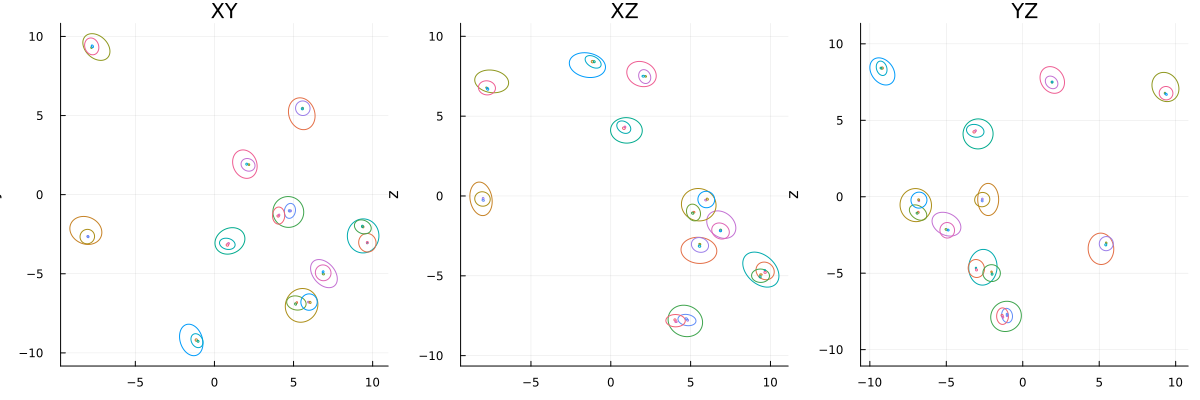

In [20]:
projector = ProjectionMapper.Projector(ellipsoids)
projections = ProjectionMapper.project_population(projector)

fig = plot_projections(projections, ellipsoids)
Plots.display(fig)  

# Incertitudes

In [27]:
# Charger configuration
config = SimulationIO.load_config("config.toml")
parents = SimulationIO.create_initial_parents(config; seed=42)

# Tester différents taux de fragmentation
frag_rates = [0.4, 0.6, 0.8, 1.0, 1.5, 2.0, 2.5, 3.0]
scaling_ratios = SimulationIO.set_scaling_ratios(config)
println(scaling_ratios)

errors = Float64[]
phi2d = Float64[]

for phi in frag_rates
    parents_test = deepcopy(parents)
    gen_test = EllipsoidFragmentation.Generator(parents_test, 
                        fill(phi, length(scaling_ratios)),
                        scaling_ratios,
                        0.9, 1e-3, 10000)
    
    ells = EllipsoidFragmentation.build_population!(gen_test; verbose=false)
    proj_test = ProjectionMapper.Projector(ells)
    projections_test = ProjectionMapper.project_population(proj_test)
    
    # Calculer erreur
    counts_3d, counts_2d = ProjectionMapper.count_by_level(proj_test.data, projections_test)

    println(counts_2d)
    max_ratio = prod(scaling_ratios)
    println(max_ratio)
    phi_mes2d = - (log( counts_2d[:xy][0]) - log( counts_2d[:xy][length(scaling_ratios)])) / log(max_ratio)
    push!(phi2d, phi_mes2d)
    
    println("φ = $phi, φ2D = $phi_mes2d")
end

[2.0]


Progress: 100%|█████████████████████████████████████████| Time: 0:00:03


Dict(:yz => Dict(0 => 100, 1 => 131), :xy => Dict(0 => 100, 1 => 131), :xz => Dict(0 => 100, 1 => 131))
2.0
φ = 0.4, φ2D = 0.38956681176272445


Progress: 100%|█████████████████████████████████████████| Time: 0:00:07


Dict(:yz => Dict(0 => 100, 1 => 152), :xy => Dict(0 => 100, 1 => 152), :xz => Dict(0 => 100, 1 => 152))
2.0
φ = 0.6, φ2D = 0.6040713236688603


...

Dict(:yz => Dict(0 => 100, 1 => 171), :xy => Dict(0 => 100, 1 => 171), :xz => Dict(0 => 100, 1 => 171))
2.0
φ = 0.8, φ2D = 0.7739963251111732


Progress: 100%|█████████████████████████████████████████| Time: 0:00:10


Dict(:yz => Dict(0 => 100, 1 => 193), :xy => Dict(0 => 100, 1 => 193), :xz => Dict(0 => 100, 1 => 193))
2.0
φ = 1.0, φ2D = 0.9486008474933552


Progress: 100%|█████████████████████████████████████████| Time: 0:00:24


Dict(:yz => Dict(0 => 100, 1 => 211), :xy => Dict(0 => 100, 1 => 211), :xz => Dict(0 => 100, 1 => 211))
2.0
φ = 1.2, φ2D = 1.0772429989324601


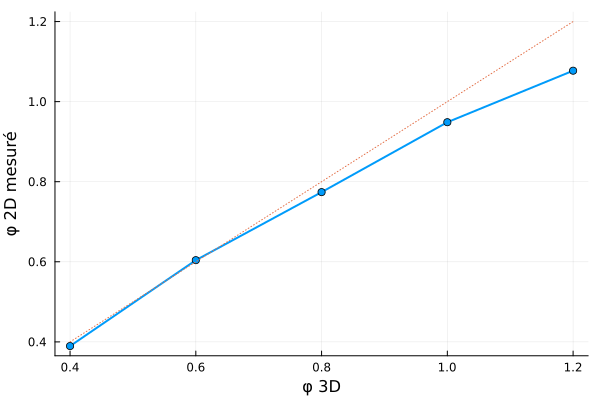

In [28]:
Plots.plot(frag_rates, phi2d,
    xlabel="φ 3D",
    ylabel="φ 2D mesuré",
    marker=:circle,
    linewidth=2,
    legend=false)

Plots.plot!(frag_rates, frag_rates,
    linestyle = :dot,
    legend=false)